# 01 - Material Database Demo

This notebook demonstrates the WeldFatigue material database.
Browse steel and aluminum grades, search by properties, and explore strain-rate parameters.

In [1]:
from weldfatigue.materials.database import MaterialDatabase

db = MaterialDatabase()
print(f"Total grades loaded: {len(db.list_grades())}")

Total grades loaded: 14


## List All Grades

In [2]:
df = db.to_dataframe()
df

,Name,Standard,Family,Yield [MPa],UTS [MPa],E [MPa],Density [kg/m3],Elongation [%]
0,DC04,EN 10130,steel,210,310,210000,7850,38
1,DP600,EN 10338,steel,350,600,210000,7850,20
2,DP780,EN 10338,steel,480,780,210000,7850,14
3,DP980,EN 10338,steel,600,980,210000,7850,10
4,HSLA340,EN 10268,steel,340,410,210000,7850,24
5,HSLA420,EN 10268,steel,420,480,210000,7850,20
6,22MnB5,EN 10083,steel,1000,1500,210000,7850,6
7,S355J2,EN 10025,steel,355,510,210000,7850,22
8,316L,EN 10088,steel,220,520,193000,7990,40
9,6061-T6,EN 573,aluminum,276,310,68900,2700,12


## Look Up a Specific Grade

In [3]:
dp600 = db.get("DP600")
print(f"Name: {dp600.name}")
print(f"Family: {dp600.family}")
print(f"Yield: {dp600.yield_strength} MPa")
print(f"UTS:   {dp600.ultimate_strength} MPa")
print(f"Density: {dp600.density} kg/m³")
print(f"Young's modulus: {dp600.youngs_modulus} MPa")

Name: DP600
Family: steel
Yield: 350 MPa
UTS:   600 MPa
Density: 7850 kg/m³
Young's modulus: 210000 MPa


## Search by Minimum Yield Strength

In [4]:
high_strength = db.search(min_yield=500)
for mat in high_strength:
    print(f"{mat.name:12s}  σy={mat.yield_strength} MPa  σu={mat.ultimate_strength} MPa  ({mat.family})")

DP980         σy=600 MPa  σu=980 MPa  (steel)
22MnB5        σy=1000 MPa  σu=1500 MPa  (steel)
7075-T6       σy=503 MPa  σu=572 MPa  (aluminum)


## Filter by Material Family

In [5]:
aluminums = db.search(family="aluminum")
for mat in aluminums:
    print(f"{mat.name:12s}  σy={mat.yield_strength} MPa  σu={mat.ultimate_strength} MPa")

6061-T6       σy=276 MPa  σu=310 MPa
6082-T6       σy=260 MPa  σu=310 MPa
5083-H111     σy=190 MPa  σu=275 MPa
5754-O        σy=80 MPa  σu=190 MPa
7075-T6       σy=503 MPa  σu=572 MPa


## Strain-Rate Parameters (Cowper-Symonds)

In [6]:
cs_params = db.get_strain_rate_params("DP600", model="cowper_symonds")
print(f"Cowper-Symonds D = {cs_params['D']}, q = {cs_params['q']}")

jc_params = db.get_strain_rate_params("DP600", model="johnson_cook")
print(f"Johnson-Cook A={jc_params['A']}, B={jc_params['B']}, n={jc_params['n']}, C={jc_params['C']}, m={jc_params['m']}")

Cowper-Symonds D = 100, q = 4.73
Johnson-Cook A=330, B=780, n=0.48, C=0.012, m=0.8


## Strain-Rate Effect Visualization

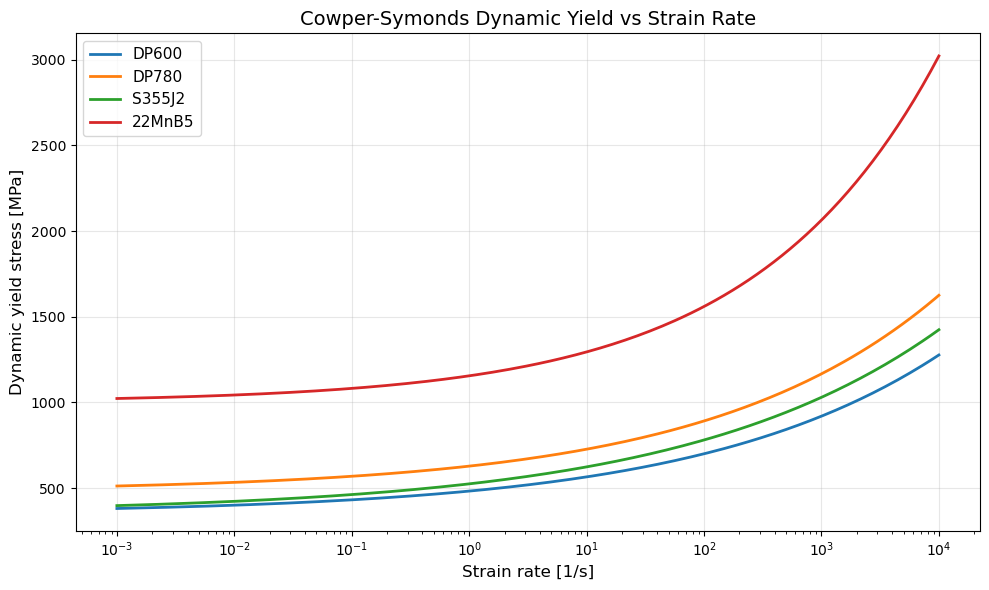

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from weldfatigue.materials.strain_rate import cowper_symonds_yield

rates = np.logspace(-3, 4, 200)

fig, ax = plt.subplots(figsize=(10, 6))
for name in ["DP600", "DP780", "S355J2", "22MnB5"]:
    mat = db.get(name)
    params = db.get_strain_rate_params(name, "cowper_symonds")
    yields = [cowper_symonds_yield(mat.yield_strength, r, params['D'], params['q']) for r in rates]
    ax.semilogx(rates, yields, label=name, linewidth=2)

ax.set_xlabel("Strain rate [1/s]", fontsize=12)
ax.set_ylabel("Dynamic yield stress [MPa]", fontsize=12)
ax.set_title("Cowper-Symonds Dynamic Yield vs Strain Rate", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()